# GeNCi Sushi — Feature Matching
**COMP7116 | Computer Vision | Session 6: Image Matching**

This notebook detects the type of sushi in a query image by performing
SIFT-based feature matching against a dataset of reference images.

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

## 1. Load Images

In [8]:
PATH      = 'Dataset/'
DATA_PATH = PATH + 'Data/'

# --- Load query (object) image ---
object_img = cv2.imread(PATH + 'Object.jpg')
object_img = cv2.cvtColor(object_img, cv2.COLOR_BGR2RGB)

# --- Load all dataset images with their filenames as labels ---
data = []   # list of (label, image_array)
for image_filename in os.listdir(DATA_PATH):
    image_path = os.path.join(DATA_PATH, image_filename)
    image_data = cv2.imread(image_path)
    if image_data is not None:
        label = os.path.splitext(image_filename)[0]   # filename without extension
        data.append((label, image_data))

print(f"Query image shape : {object_img.shape}")
print(f"Dataset size      : {len(data)} images")

Query image shape : (2001, 3000, 3)
Dataset size      : 5 images


## 2. Preprocess & Extract Features from Query Image

In [9]:
def preprocess(img_rgb):
    """Convert to grayscale, denoise, and equalise histogram."""
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    gray = cv2.medianBlur(gray, 3)        # remove noise
    gray = cv2.equalizeHist(gray)         # improve contrast
    return gray

# Create SIFT detector
sift = cv2.AKAZE_create()

# Preprocess query image
grayscale_object = preprocess(object_img)

# Extract query keypoints & descriptors
target_keypoint, target_desc = sift.detectAndCompute(grayscale_object, None)
target_desc = np.float32(target_desc)

print(f"Query keypoints found: {len(target_keypoint)}")

Query keypoints found: 6907


## 3. Match Query Against Every Dataset Image

**Fix:** The FLANN matching and best-match tracking are now **inside** the loop,
so every dataset image is compared against the query image.
`current_match` is reset to `0` at the start of each iteration.

In [10]:
# FLANN parameters for float (SIFT) descriptors
index_param  = dict(algorithm=1, trees=5)   # FLANN_INDEX_KDTREE
search_param = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_param, search_param)

best_match      = 0
best_match_data = None   # FIX: initialise to None to avoid NameError

# ─── FIX: entire matching pipeline is INSIDE the loop ───
for label, img_bgr in data:

    # Convert BGR → RGB then preprocess
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_gray = preprocess(img_rgb)

    # Extract features for this dataset image
    img_keypoint, img_desc = sift.detectAndCompute(img_gray, None)
    if img_desc is None or len(img_desc) < 2:
        print(f"  [skip] {label} — not enough keypoints")
        continue
    img_desc = np.float32(img_desc)

    # kNN match (k=2) + Lowe's ratio test
    match         = flann.knnMatch(target_desc, img_desc, k=2)
    matches_mask  = [[0, 0] for _ in range(len(match))]
    current_match = 0   # FIX: reset counter for each image

    for i, pair in enumerate(match):
        if len(pair) < 2:
            continue
        fm, sm = pair
        if fm.distance < 0.7 * sm.distance:   # Lowe's ratio test
            matches_mask[i] = [1, 0]
            current_match  += 1

    print(f"  {label:30s} → {current_match:4d} good matches")

    # Keep track of best-matching dataset image
    if current_match > best_match:
        best_match      = current_match
        best_match_data = {
            'label'       : label,
            'image_data'  : img_gray,
            'keypoint'    : img_keypoint,
            'description' : img_desc,
            'match'       : match,
            'matchesMask' : matches_mask,
        }

# ─── FIX: guard against no match found ───
if best_match_data is None:
    print("\n[ERROR] No matching image found in the dataset.")
else:
    print(f"\n>>> Best match: '{best_match_data['label']}' with {best_match} good matches <<<")

  1                              →    8 good matches
  2                              →    2 good matches
  3                              →    0 good matches
  4                              →    4 good matches
  5                              →    3 good matches

>>> Best match: '1' with 8 good matches <<<


## 4. Visualise Feature Matching Result

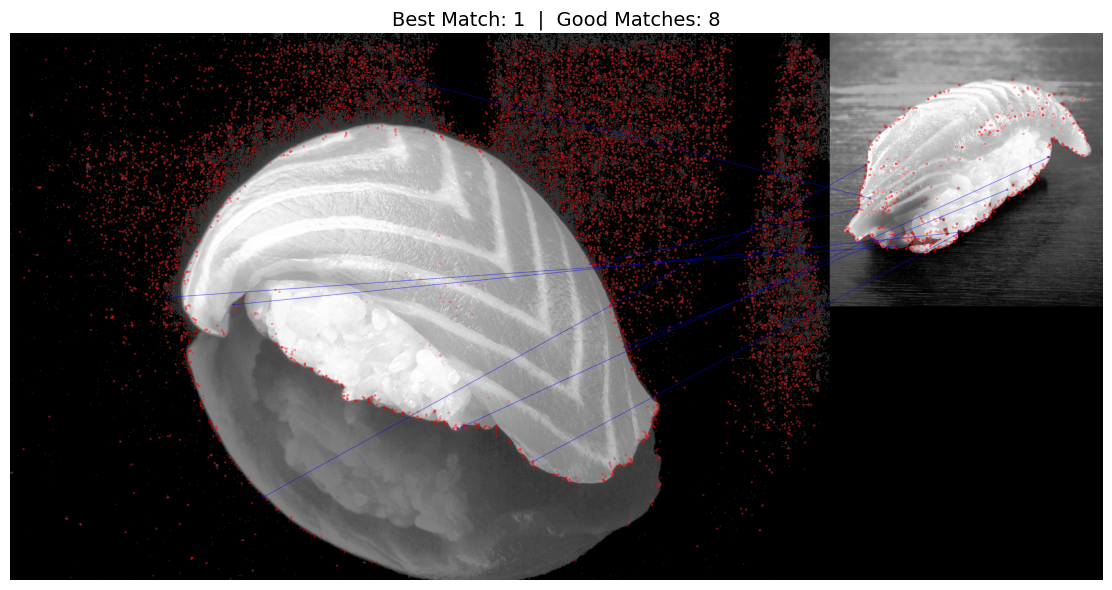

In [11]:
if best_match_data is not None:
    result = cv2.drawMatchesKnn(
        grayscale_object,
        target_keypoint,
        best_match_data['image_data'],
        best_match_data['keypoint'],
        best_match_data['match'],
        None,
        matchesMask    = best_match_data['matchesMask'],
        matchColor     = [0, 0, 255],     # blue lines for good matches
        singlePointColor = [255, 0, 0],   # red dots for unmatched keypoints
    )

    plt.figure(figsize=(14, 6))
    plt.imshow(result, cmap='gray')
    plt.title(
        f"Best Match: {best_match_data['label']}  |  Good Matches: {best_match}",
        fontsize=14
    )
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Nothing to display — no match was found.")